# Loading Necessary Packages

- All are very widely used, despite "pnadium," which is the package we use to load the dataset.

In [6]:
import pnadium
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold, cross_val_score
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Loading and Cleaning the Dataset

We will be using the dataset from the 2nd Quarter of 2025

In [8]:
pnad = pnadium.trimestral.download(ano=2025, t=2) # loading the DS
pnad = pnad.drop(['Ano', 'Trimestre', 'RM_RIDE', 'UPA', 'Estrato', 'COD_FAM', 'COD_PESSOA'], axis=1) # Dropping unnecessary features
df = pnad.copy()

Iniciou o download: Trimestre 2/2025 - aguarde.
Download finalizado.
Iniciou a criação do DataFrame Pandas: esta etapa pode demorar alguns minutos.
Chunks processados e salvos.
DataFrame criado.


In [9]:
df = df.drop(['V403312','V403322','V405012','V405812','V405821','V405822','VD4016','VD4020'], axis=1)
df = df.drop(['V403311', 'V403321', 'V403411', 'V403412','V405011', 'V405112', 'V405121', 'V405122','V405811', 'V405912', 'VD4017'],axis=1) 

# Dropping more features that were overfitting lasso
# They were very similar to income, so they were making the prediction biased

In [10]:
df

,UF,Capital,V1008,V1014,V1016,V1022,V1023,V1027,V1028,V1029,...,V1028191,V1028192,V1028193,V1028194,V1028195,V1028196,V1028197,V1028198,V1028199,V1028200
0,11,11.0,01,12,3,1,1,299.388679,370.470690,517823,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
1,11,11.0,01,12,3,1,1,299.388679,370.470690,517823,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
2,11,11.0,01,12,3,1,1,299.388679,370.470690,517823,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
3,11,11.0,01,12,3,1,1,299.388679,370.470690,517823,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
4,11,11.0,01,12,3,1,1,299.388679,370.470690,517823,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475585,53,53.0,13,12,4,2,1,193.675834,243.389427,2996947,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261
475586,53,53.0,13,12,4,2,1,193.675834,243.389427,2996947,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261
475587,53,53.0,13,12,4,2,1,193.675834,243.389427,2996947,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261
475588,53,53.0,14,12,4,2,1,193.675834,181.038434,2996947,...,193.952705,0.0,202.032884,181.202196,593.147235,195.248364,184.962040,375.542863,186.568313,376.088450


In [11]:
df = df.drop('Capital', axis=1) # Useless feature to remove
df = df.drop(["V1008", "V1014"], axis=1) # Dropping more unnecessary features

In [12]:
df = df[df["V2009"] >= 18] # Removing everyone below 18 years of age

In [13]:
df

,UF,V1016,V1022,V1023,V1027,V1028,V1029,V1033,posest,posest_sxi,...,V1028191,V1028192,V1028193,V1028194,V1028195,V1028196,V1028197,V1028198,V1028199,V1028200
0,11,3,1,1,299.388679,370.470690,517823,3026332,111,217,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
1,11,3,1,1,299.388679,370.470690,517823,6347352,111,212,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
2,11,3,1,1,299.388679,370.470690,517823,6286664,111,111,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
3,11,3,1,1,299.388679,370.470690,517823,7979836,111,107,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
5,11,3,1,1,299.388679,273.917916,517823,5724269,111,213,...,0.000000,0.0,305.688538,270.468273,283.794669,0.000000,297.187715,0.000000,803.851839,632.663891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475584,53,4,2,1,193.675834,243.389427,2996947,7865118,531,210,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261
475585,53,4,2,1,193.675834,243.389427,2996947,7334313,531,110,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261
475586,53,4,2,1,193.675834,243.389427,2996947,7921315,531,105,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261
475588,53,4,2,1,193.675834,181.038434,2996947,6347352,531,212,...,193.952705,0.0,202.032884,181.202196,593.147235,195.248364,184.962040,375.542863,186.568313,376.088450


In [14]:
df = df.dropna(subset=['VD4019']) # Drop everyone's incomes that are missing!
df = df.fillna(0) # There are many N/A that we will just fill with 0! Won't overlap with other responses, so it's fine!

In [15]:
df

,UF,V1016,V1022,V1023,V1027,V1028,V1029,V1033,posest,posest_sxi,...,V1028191,V1028192,V1028193,V1028194,V1028195,V1028196,V1028197,V1028198,V1028199,V1028200
2,11,3,1,1,299.388679,370.470690,517823,6286664,111,111,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
3,11,3,1,1,299.388679,370.470690,517823,7979836,111,107,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
6,11,3,1,1,299.388679,383.565718,517823,8310816,111,208,...,0.000000,0.0,401.601780,377.005854,402.832840,0.000000,424.491560,0.000000,1165.791807,847.460773
7,11,3,1,1,299.388679,383.565718,517823,8310816,111,208,...,0.000000,0.0,401.601780,377.005854,402.832840,0.000000,424.491560,0.000000,1165.791807,847.460773
8,11,3,1,1,299.388679,383.565718,517823,8019965,111,108,...,0.000000,0.0,401.601780,377.005854,402.832840,0.000000,424.491560,0.000000,1165.791807,847.460773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475581,53,4,2,1,193.675834,228.860209,2996947,7334313,531,110,...,234.215635,0.0,254.799161,241.187607,768.879212,258.722749,245.431115,467.741539,245.010739,466.638368
475582,53,4,2,1,193.675834,228.860209,2996947,6866767,531,211,...,234.215635,0.0,254.799161,241.187607,768.879212,258.722749,245.431115,467.741539,245.010739,466.638368
475585,53,4,2,1,193.675834,243.389427,2996947,7334313,531,110,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261
475586,53,4,2,1,193.675834,243.389427,2996947,7921315,531,105,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261


- We have 392 features (1 extra column in the dependent variable)
- 205,198 rows, so many individuals.
- We have roughly ~205k people for the model.

In [17]:
print(df.columns[df.isna().any()].tolist()) 
# Not a single N/A value

[]


# Understanding the Target Variable

In [19]:
df["VD4019"].describe()

# Very skewed

count    205198.000000
mean       3227.799618
std        4658.960753
min          10.000000
25%        1518.000000
50%        2000.000000
75%        3300.000000
max      250000.000000
Name: VD4019, dtype: float64

Text(0.5, 1.0, 'Histogram of VD4019')

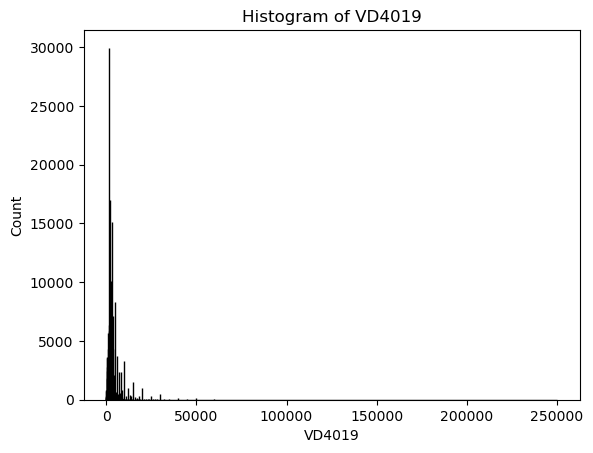

In [20]:
plt.hist(df["VD4019"], bins=10000, edgecolor="black")
plt.xlabel("VD4019")
plt.ylabel("Count")
plt.title("Histogram of VD4019")

Very skewed data, so we want to remove some outliers!

In [22]:
df["VD4019"].mean() + 6*df["VD4019"].std()

# So, ~30,000 seems to be a fairly good number, since 6 stdev away, and we can clean lots of outliers!

31181.564137077923

(0.0, 30000.0)

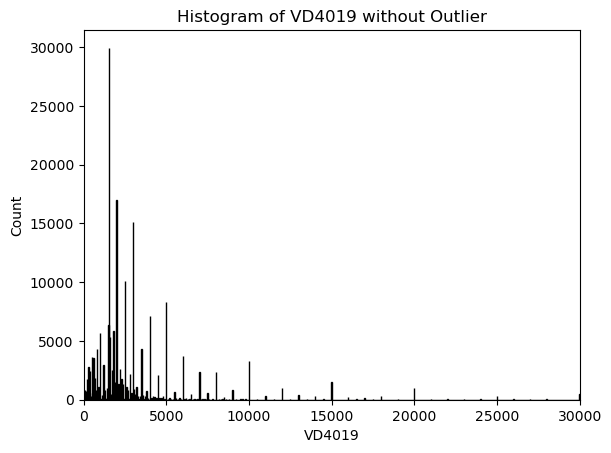

In [23]:
plt.hist(df["VD4019"], bins=10000, edgecolor="black")
plt.xlabel("VD4019")
plt.ylabel("Count")
plt.title("Histogram of VD4019 without Outlier")
plt.xlim(0, 30000)  # or plt.ylim(0, 25000)

In [24]:
# Seems great now, easier to look at data, and we still have higher incomes, so not totally desconsidering

In [25]:
df = df[df["VD4019"] <= 30000]

In [26]:
df

,UF,V1016,V1022,V1023,V1027,V1028,V1029,V1033,posest,posest_sxi,...,V1028191,V1028192,V1028193,V1028194,V1028195,V1028196,V1028197,V1028198,V1028199,V1028200
2,11,3,1,1,299.388679,370.470690,517823,6286664,111,111,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
3,11,3,1,1,299.388679,370.470690,517823,7979836,111,107,...,0.000000,0.0,386.052699,364.309477,388.448283,0.000000,410.305414,0.000000,1134.142520,827.889206
6,11,3,1,1,299.388679,383.565718,517823,8310816,111,208,...,0.000000,0.0,401.601780,377.005854,402.832840,0.000000,424.491560,0.000000,1165.791807,847.460773
7,11,3,1,1,299.388679,383.565718,517823,8310816,111,208,...,0.000000,0.0,401.601780,377.005854,402.832840,0.000000,424.491560,0.000000,1165.791807,847.460773
8,11,3,1,1,299.388679,383.565718,517823,8019965,111,108,...,0.000000,0.0,401.601780,377.005854,402.832840,0.000000,424.491560,0.000000,1165.791807,847.460773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475581,53,4,2,1,193.675834,228.860209,2996947,7334313,531,110,...,234.215635,0.0,254.799161,241.187607,768.879212,258.722749,245.431115,467.741539,245.010739,466.638368
475582,53,4,2,1,193.675834,228.860209,2996947,6866767,531,211,...,234.215635,0.0,254.799161,241.187607,768.879212,258.722749,245.431115,467.741539,245.010739,466.638368
475585,53,4,2,1,193.675834,243.389427,2996947,7334313,531,110,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261
475586,53,4,2,1,193.675834,243.389427,2996947,7921315,531,105,...,254.837224,0.0,263.761673,246.723934,795.845198,268.668099,255.569430,500.394847,252.261175,507.928261


392 features

204,469 individuals now!

In [28]:
df["VD4019"].describe()

count    204469.000000
mean       3062.045259
std        3461.922271
min          10.000000
25%        1518.000000
50%        2000.000000
75%        3200.000000
max       30000.000000
Name: VD4019, dtype: float64

# Feature Selection & Lasso Regression with Hyperparameter Tuning

In [30]:
X = df.drop("VD4019", axis=1).fillna(0)
y = df["VD4019"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
# Train-Test Split

Scaling the data:

In [32]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_val_sc = scaler.transform(X_val)

**Machine was having trouble running the pipeline for Lasso, so I will manually set up a few so that you can see my work.**

Lasso: Alpha = 1

Any lower alpha just does not run, so I had to set up "high" alphas

In [35]:
lasso_1 = Lasso(alpha=1, max_iter=20000, random_state=42)

lasso_1.fit(X_train_sc, y_train)
y_val_pred_1 = lasso_1.predict(X_val_sc)
print("alpha=1  | R2:", r2_score(y_val, y_val_pred_1),
      "MAE:", mean_absolute_error(y_val, y_val_pred_1),
      "RMSE:", mean_squared_error(y_val, y_val_pred_1)**0.5)

alpha=1  | R2: 0.4573494385641591 MAE: 1453.5158218988374 RMSE: 2546.691205270697


Lasso: Alpha = 5

In [37]:
lasso_5 = Lasso(alpha=5, max_iter=20000, random_state=42)

lasso_5.fit(X_train_sc, y_train)
y_val_pred_5 = lasso_5.predict(X_val_sc)
print("alpha=5  | R2:", r2_score(y_val, y_val_pred_5),
      "MAE:", mean_absolute_error(y_val, y_val_pred_5),
      "RMSE:", mean_squared_error(y_val, y_val_pred_5)**0.5)

alpha=5  | R2: 0.4540455188779099 MAE: 1456.0285542641152 RMSE: 2554.4321857667555


Lasso: Alpha = 10

In [39]:
lasso_10 = Lasso(alpha=10, max_iter=20000, random_state=42)

lasso_10.fit(X_train_sc, y_train)
y_val_pred_10 = lasso_10.predict(X_val_sc)
print("alpha=10  | R2:", r2_score(y_val, y_val_pred_10),
      "MAE:", mean_absolute_error(y_val, y_val_pred_10),
      "RMSE:", mean_squared_error(y_val, y_val_pred_10)**0.5)

alpha=10  | R2: 0.449436031001591 MAE: 1461.108402188538 RMSE: 2565.1930419445716


# We got the best results from Alpha = 1, so we will stick with that.

# Now, let's look at the selected features + coefficients

In [41]:
print("# Non-zero coefficients:", (lasso_1.coef_ != 0).sum())

# Non-zero coefficients: 298


In [42]:
coef = lasso_1.coef_
selected_mask = coef != 0
selected_features = X.columns[selected_mask].tolist()
print("Selected features:", selected_features[:10])

Selected features: ['UF', 'V1016', 'V1022', 'V1023', 'V1027', 'V1029', 'V1033', 'posest_sxi', 'V2001', 'V2003']


# Top 10 features by coefficient

In [43]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "coef": lasso_1.coef_
}).sort_values("coef", key=abs, ascending=False)

top_features = importance_df[importance_df.coef != 0]
print(top_features.head(10))

     feature         coef
23    V3003A  2147.027131
32    V3009A  2043.566917
175   VD4009  2014.422309
60     V4014 -1607.703869
61     V4015 -1146.437121
121  V405111   950.095730
36     V3012  -881.255661
55     V4012   859.335721
76     V4019  -751.066704
69     V4017  -647.044437


Variables with high coefficients according to dictionary (in order):
- V3003A: Which course does the person attend? High school, college, PhD, etc.
- V3009A: Highest level of degree
- VD4009: Rank at job
- V4014: Level of work: Federal, state-level, etc.
- V4015: Was assisted by another family member on work
- V405111: Average daily withdrawal from business
- V3012: Concluded first grade?
- V4012: Type of work
- V4019: Registered business? Y/N
- V4017: Did they have a partner in the business?

**Interesting to see variables that have high coefficients, because they are all labeled numerically, 
so this shows that the model gives big emphasis to these variables**

Especially the first 5!

So education and rank of job seem to be very important when predicting income.

# Looking at Lasso Prediction vs. Actual

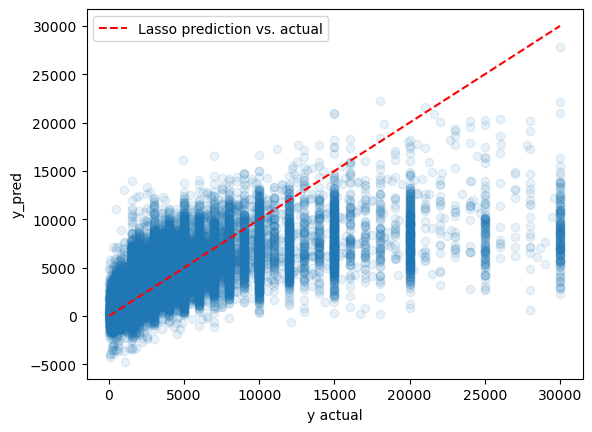

In [87]:
plt.scatter(y_val, y_val_pred_1, alpha=0.1)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],"r--", label="Lasso prediction vs. actual")
plt.xlabel("y actual")
plt.ylabel("y_pred")
plt.legend()

Model seems to underestimate higher incomes.

Predictions are faily good up until ~R$10k, but then it starts getting more residuals

# Residual Distribution

Text(0.5, 1.0, 'Residual distribution')

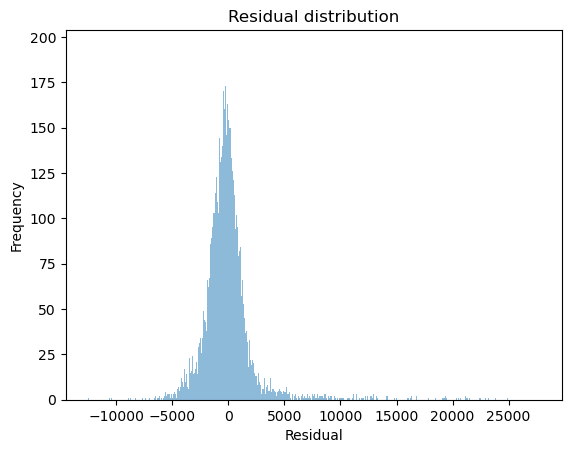

In [98]:
res = y_val - y_val_pred_1

plt.hist(res, bins=5000, alpha=0.5)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual distribution")

In [ ]:
res.mean()

Again, we see from the residuals plot that we more often "under-estimate" than "over-estimate" showing that a non-linear model could fit well!

This makes sense as income tends to follow Power Law distributions

# Random Forest Regressor - Tree-based Model

In [107]:
# Much of the literature mentioned RF as the best model to predict income, so we will use this regressor to predict income.

In [117]:
y = df["VD4019"]
X = df[selected_features]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Nice that we are using the best features from the Lasso Regression, that way we can see directly if Random Forest improved predictions

# Hyperparameter Tuning

In [122]:
rf_param_dist = {
    'n_estimators': [300],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [5],
    'max_features': ['sqrt', 'log2']
}

**Not many parameters changed b/c too computationally intensive for my computer.**

# Running the Random Forest Models

In [127]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_random = RandomizedSearchCV(rf, rf_param_dist, n_iter=12, cv=3, scoring='r2', verbose=2)

rf_random.fit(X_train, y_train)

# We want to explain the most variance, so we will use R^2 as the scoring method

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=300; total time=  18.3s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=300; total time=  17.8s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=300; total time=  17.4s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=300; total time=  17.5s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=300; total time=  18.0s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=300; total time=  18.1s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=5, min_samples_split=2, n_estimators=300; total time=  10.3s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=5, min_samples_split=2, n_estimators=300

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [15, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [5], 'min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versioncha

# Getting the best parameters and re-running the model

In [141]:
print('Best params:', rf_random.best_params_)
best_rf = rf_random.best_estimator_
y_val_pred = best_rf.predict(X_val)
y_test_pred = best_rf.predict(X_test)

Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}


# Random Forest: Model Performance

In [145]:
print('Val R2:', r2_score(y_val, y_val_pred))  
print('Val RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
print('Val MAE:', mean_absolute_error(y_val, y_val_pred))

Val R2: 0.519148051138515
Val RMSE: 2429.7696287631425
Val MAE: 1294.692344652997


Great results, looks like the model is performing better than Lasso.

All of the scores in validation seem higher, we will check them later with X_train if they are actually better when comparing to Lasso.

Model still seems sensible to outliers as MAE >> RMSE.

Roughly 52% of the variance can be explained by the model, which is great considering how income is difficult to track.

# Most Important Features of Random Forest Model

In [169]:
importances = best_rf.feature_importances_
rf_importance_df = pd.DataFrame({"feature": X.columns,"importance": importances}).sort_values("importance", ascending=False)

print(rf_importance_df.head(10))

     feature  importance
36     V4010    0.059973
109   VD3004    0.047639
110   VD3005    0.045045
111   VD3006    0.036337
24    V3009A    0.036296
115   VD4011    0.035513
78    V40403    0.021988
46     V4016    0.016921
93   V405111    0.016060
116   VD4012    0.014613


Important Variables:

- V4010: "Occupation code"
- VD3004: Highest level of education achieved
- VD3005: Years of study   
- VD3006: Standardized data for years of study   
- V3009A: Highest level of education attended (not necessarily graduated)    
- VD4011: Occupational group  
- V40403: How long did that person work that job    
- V4016:  How many employees in your business  
- V405111: Range of monthly withdrawals from business  
- VD4012: Did that person contribute to social security? Y/N

Very interesting again that the model is focusing on education and occupation. 

Education seems to be a very good predictor of income, according to our model.

# Random Forest Trees - Figure

Text(0.5, 1.0, 'Random Forest tree')

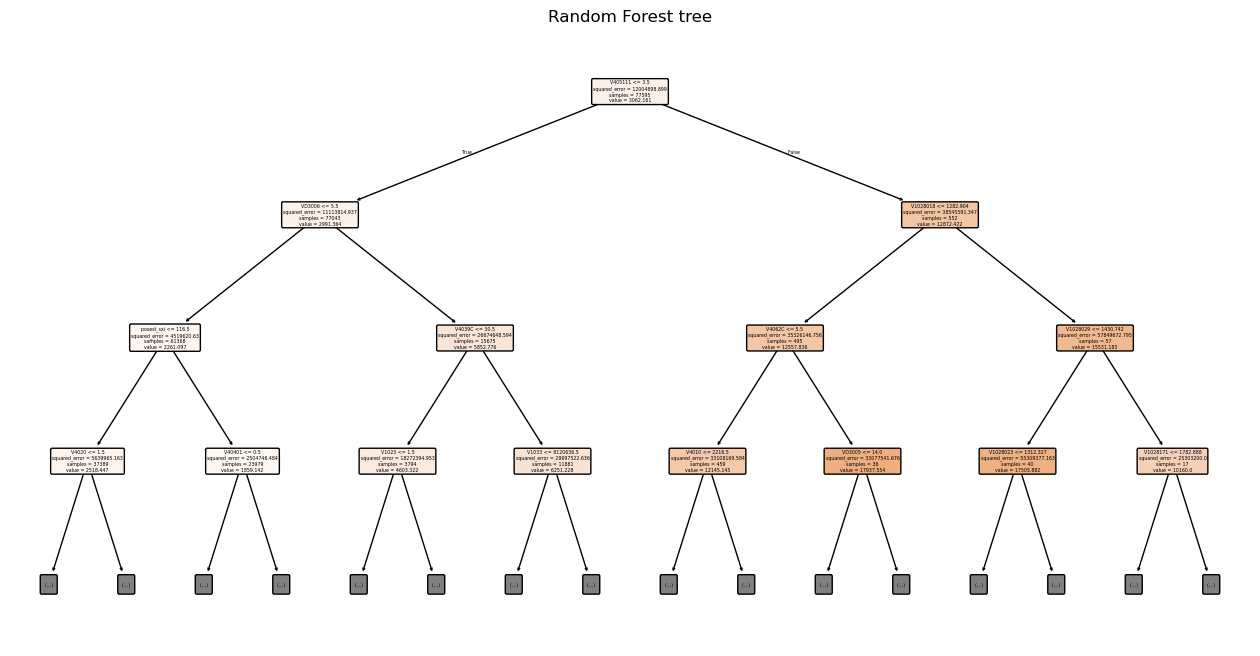

In [180]:
plt.figure(figsize=(16, 8))
plot_tree(rf_random.best_estimator_.estimators_[0],feature_names=X.columns,filled=True,rounded=True,max_depth=3)
plt.title("Random Forest tree")

In [182]:
# Range of monthly withdrawals from business is the first question!

# Looking at RF Prediction vs. Actual

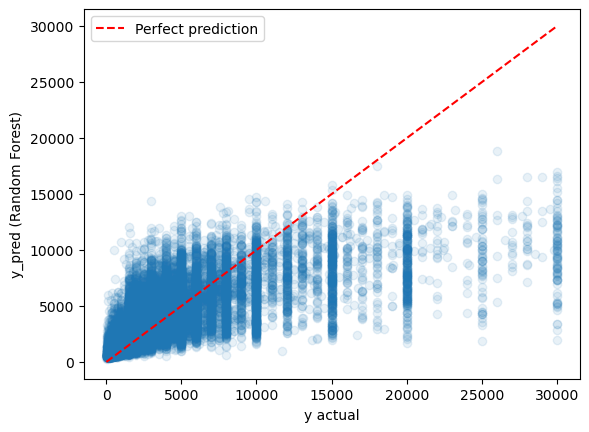

In [190]:
plt.scatter(y_val, y_val_pred, alpha=0.1)
plt.plot([y_val.min(), y_val.max()],[y_val.min(), y_val.max()],"r--",label="Perfect prediction")
plt.xlabel("y actual")
plt.ylabel("y_pred (Random Forest)")
plt.legend()

**The model still seems to be facing the same problem of "underestimating" higher incomes. Interestingly, we see a cluster problem here perhaps.**

**Perhaps if we cluster the predictions, we could actually see another interesting pattern**

# Residual Distribution

Text(0.5, 1.0, 'Residual distribution')

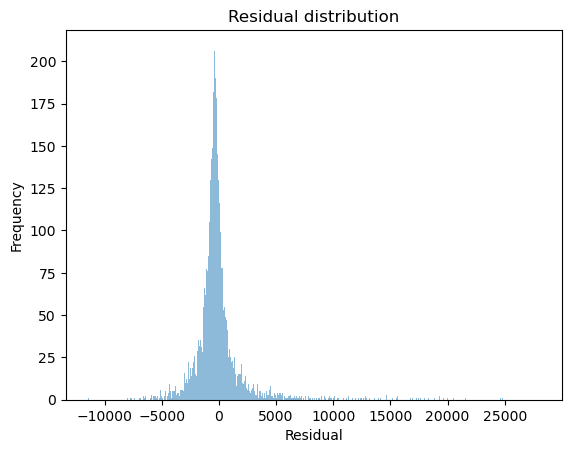

In [199]:
res = y_val - y_val_pred

plt.hist(res, bins=5000, alpha=0.5)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual distribution")

In [203]:
res.mean() # mean of residuals

-64.40758297207698

In [209]:
res.median() # median of residuals

-354.35613057535727

# Model Comparison: X_test, y_test

Re-running the Lasso DS

I first ran the model with all features, but re-running the Lasso would not work as the new X_train had less features (we dropped some),
so to be fair, I decided to run another X_train with selected_features and run the Lasso on those features.

So, now we had to use another random test ds so that the lasso ran fairly.

In [218]:
X_sel = X[selected_features]

X_temp, X_test_sel, y_temp, y_test_sel = train_test_split(
    X_sel, y, test_size=0.2, random_state=42
)
X_train_sel, X_val_sel, y_train_sel, y_val_sel = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

scaler = StandardScaler()
scaler.fit(X_train_sel)
X_train_sc = scaler.transform(X_train_sel)
X_val_sc   = scaler.transform(X_val_sel)
X_test_sc  = scaler.transform(X_test_sel)

lasso_1 =  Lasso(alpha=1, max_iter=20000, random_state=42)
lasso_1.fit(X_train_sc, y_train_sel)

y_test_pred_lasso = lasso_1.predict(X_test_sc)

In [224]:
r2_lasso_test = r2_score(y_test, y_test_pred_lasso)
mae_lasso_test = mean_absolute_error(y_test, y_test_pred_lasso)
rmse_lasso_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))

print("Lasso (alpha=1) - test R^2:", r2_lasso_test)
print("Lasso (alpha=1) - test MAE:", mae_lasso_test)
print("Lasso (alpha=1) - test RMSE:", rmse_lasso_test)

Lasso (alpha=1) - test R^2: 0.4569315615045414
Lasso (alpha=1) - test MAE: 1451.4875601450065
Lasso (alpha=1) - test RMSE: 2531.5746757877046


In [226]:
r2_rf_test = r2_score(y_test, y_test_pred_rf)
mae_rf_test = mean_absolute_error(y_test, y_test_pred_rf)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("Random Forest - test R^2:", r2_rf_test)
print("Random Forest - test MAE:", mae_rf_test)
print("Random Forest - test RMSE:", rmse_rf_test)

Random Forest - test R^2: 0.5154567574459661
Random Forest - test MAE: 1269.523959877048
Random Forest - test RMSE: 2391.276145155048


In [228]:
# Across all score metrics, we get better results with the Random Forest, showing that it could sucessfully capture the non-linearities of the data.